# Compare outFLANK and Bayescan putative outliers

In [2]:
library("ggplot2")
library("dplyr")

outflank dataframe 

In [10]:
all_loci <- read.csv("outFLANK/outFLANK_FST.csv") %>%
    select(LocusName, He, FST, FSTNoCorr, OutlierFlag) %>%
    mutate(LocusName = gsub("\\.[0-9]+", "", LocusName))

all_outflank <- filter(all_loci, OutlierFlag == TRUE)
all_outflank_putatives <- all_outflank$LocusName


Outflank and Bayescan results 

In [11]:
out_bayescan <- readLines("bayescan/bayescan_outliers.txt")
bayescan_idx <- c()

all shared putative outliers regardless of He <- used in graphic

In [12]:
all_shared <- intersect(out_bayescan, all_outflank_putatives)
all_onlybayes <- setdiff(out_bayescan, all_shared)
all_onlyoutflnk <- setdiff(all_outflank_putatives, all_shared)
all_nonout <- setdiff(all_loci$LocusName, c(all_onlybayes, all_onlyoutflnk, all_shared))


only shared putative outliers (He threshold) <- used in publication

In [14]:
out_shared <- intersect(out_bayescan, out_outflank)
out_only_baye <- setdiff(out_bayescan, out_shared)
out_only_outf <- setdiff(out_outflank, out_shared)
non_out <- setdiff(all_loci$LocusName, c(out_bayescan, out_outflank, out_shared))


fancy ggplot

In [31]:
mycolors <- c("#f4cf30", "#63b057", "#bbbbbb", "#4172c1")

all_loci <- all_loci %>%
  mutate(
    outlier = case_when(
      (LocusName %in% all_onlybayes) ~ "bayescan",
      (LocusName %in% all_onlyoutflnk) ~ "outflank",
      (LocusName %in% all_shared) ~ "bayescan + outflank",
      (LocusName %in% all_nonout) ~ "neutral"
    )
  )


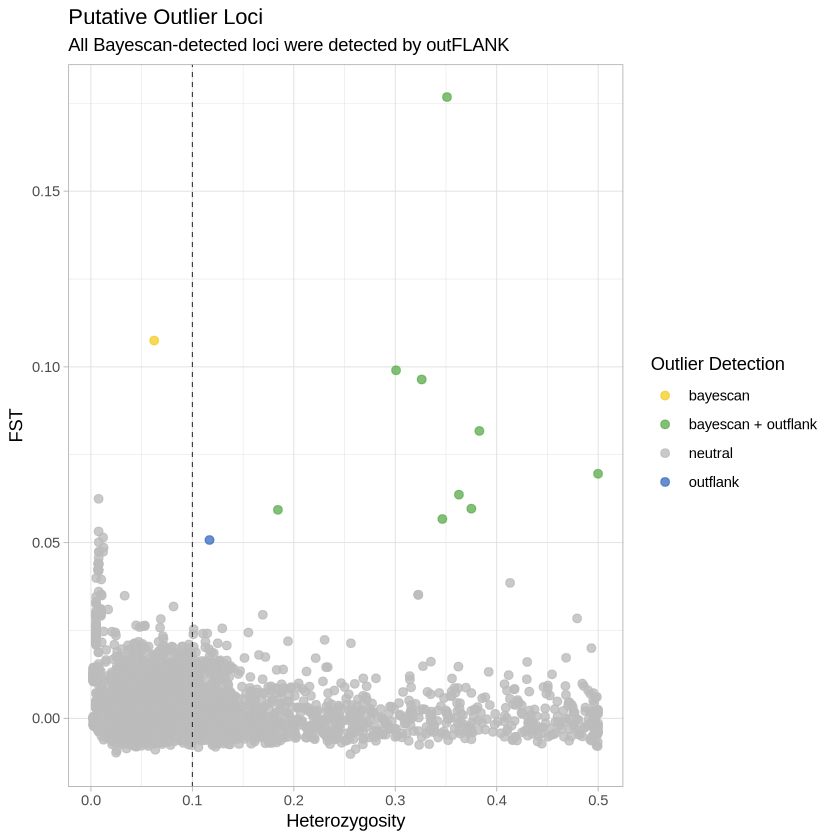

In [34]:
all_loci %>%
    ggplot(aes(x = He, y = FST, col = outlier)) +
    geom_point(alpha = 0.8, size = 2.1) +
    geom_vline(xintercept = 0.1, alpha = 0.8, linetype = "dashed", size = 0.3) +
    labs(
        title = "Putative Outlier Loci", x = "Heterozygosity", y = "FST", color = "Outlier Detection",
        subtitle = "All Bayescan-detected loci were detected by outFLANK"
    ) +
    scale_color_manual(values = mycolors) +
    theme_light()

In [35]:
ggsave("outlierplots.png", height = 6, width = 12, units = "in")
#save.image(file = "outliers.rdata")
write.table(
    all_loci,
    file = "bscan_outflank_outliers.txt",
    row.names = FALSE,
    quote = FALSE
)
